# 🚀 SOTA Time Series Forecasting - Giảm MSE Tối Đa

Notebook này sử dụng các phương pháp State-of-the-Art (SOTA) nhất hiện tại để dự đoán giá chứng khoán FPT với mục tiêu giảm MSE đến mức tối đa.

## Các phương pháp SOTA được sử dụng:
1. **PatchTST** - Patch Time Series Transformer (SOTA 2023-2024)
2. **TimesNet** - 2D Convolutional Architecture cho Time Series
3. **DLinear/NLinear** - Linear models nhưng rất hiệu quả
4. **N-BEATS/N-HiTS** - Neural Basis Expansion
5. **Autoformer** - Transformer-based với auto-correlation
6. **Ensemble** - Kết hợp tất cả các models tốt nhất


## 1. Setup và Load Dữ Liệu


In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os
from pathlib import Path

# Set encoding để tránh lỗi Unicode
import sys
import io
if sys.platform == 'win32':
    sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding='utf-8')
    sys.stderr = io.TextIOWrapper(sys.stderr.buffer, encoding='utf-8')

print("✓ Đã import các thư viện cơ bản")


✓ Đã import các thư viện cơ bản


In [68]:
# Tự động download file FPT_train.csv từ Google Drive
from pathlib import Path
import os
import subprocess

# Google Drive file ID
DRIVE_FILE_ID = "1nS9xshut38SJEX__PD_zjKFtj2CQCn7S"
DRIVE_LINK = f"https://drive.google.com/uc?export=download&id={DRIVE_FILE_ID}"

csv_path = Path("./FPT_train.csv")

# Kiểm tra xem file đã tồn tại chưa
if csv_path.exists():
    print(f"✓ File đã tồn tại tại: {csv_path}")
else:
    print("📥 Đang download file FPT_train.csv từ Google Drive...")
    
    try:
        # Thử dùng gdown (nhanh và đáng tin cậy hơn)
        try:
            import gdown
        except ImportError:
            print("   Đang cài đặt gdown...")
            subprocess.run(["pip", "install", "-q", "gdown"], check=True)
            import gdown
        
        # Download file
        gdown.download(f"https://drive.google.com/uc?id={DRIVE_FILE_ID}", str(csv_path), quiet=False)
        
        if csv_path.exists():
            print(f"✓ Đã download file thành công tại: {csv_path}")
        else:
            raise Exception("Download không thành công")
            
    except Exception as e:
        print(f"⚠️  Lỗi khi download bằng gdown: {e}")
        print("   Đang thử phương pháp khác...")
        
        # Fallback: dùng urllib
        try:
            import urllib.request
            print("   Đang download bằng urllib...")
            urllib.request.urlretrieve(DRIVE_LINK, str(csv_path))
            
            if csv_path.exists() and csv_path.stat().st_size > 0:
                print(f"✓ Đã download file thành công tại: {csv_path}")
            else:
                raise Exception("File download không hợp lệ")
        except Exception as e2:
            print(f"❌ Lỗi khi download: {e2}")
            print(f"   Vui lòng download thủ công từ: https://drive.google.com/file/d/{DRIVE_FILE_ID}/view")
            raise

# Kiểm tra lại file đã tồn tại
if not csv_path.exists():
    # Tìm file ở các vị trí khác (fallback)
    csv_paths = [
        Path("../FPT_train.csv"),
    ]
    
    for path in csv_paths:
        if path.exists():
            csv_path = path
            print(f"✓ Tìm thấy file tại: {csv_path}")
            break

# Kiểm tra cuối cùng
if not csv_path.exists():
    raise FileNotFoundError(
        f"Không tìm thấy FPT_train.csv. Vui lòng:\n"
        f"1. Kiểm tra kết nối internet để download từ Google Drive\n"
        f"2. Hoặc download thủ công từ: https://drive.google.com/file/d/{DRIVE_FILE_ID}/view"
    )

print(f"\n✓ Sẵn sàng sử dụng file: {csv_path}")

# Load dữ liệu
df = pd.read_csv(csv_path, parse_dates=["time"])
df = df.sort_values("time").reset_index(drop=True)

print(f"\n📊 Thông tin dữ liệu:")
print(f"   - Tổng số dòng: {len(df):,}")
print(f"   - Ngày đầu tiên: {df['time'].min()}")
print(f"   - Ngày cuối cùng: {df['time'].max()}")
print(f"   - Các cột: {list(df.columns)}")
print(f"\n📅 5 dòng đầu:")
print(df.head())
print(f"\n📅 5 dòng cuối:")
print(df.tail())


✓ File đã tồn tại tại: FPT_train.csv

✓ Sẵn sàng sử dụng file: FPT_train.csv

📊 Thông tin dữ liệu:
   - Tổng số dòng: 1,149
   - Ngày đầu tiên: 2020-08-03 00:00:00
   - Ngày cuối cùng: 2025-03-10 00:00:00
   - Các cột: ['time', 'open', 'high', 'low', 'close', 'volume', 'symbol']

📅 5 dòng đầu:
        time   open   high    low  close   volume symbol
0 2020-08-03  19.07  19.63  19.03  19.63  1392200    FPT
1 2020-08-04  19.89  20.01  19.76  19.91  1051310    FPT
2 2020-08-05  19.89  20.16  19.78  20.10  1328520    FPT
3 2020-08-06  20.10  20.21  19.97  20.01  1153660    FPT
4 2020-08-07  20.01  20.44  20.01  20.14  1283690    FPT

📅 5 dòng cuối:
           time    open    high     low   close   volume symbol
1144 2025-03-04  120.28  121.23  120.11  120.71  3480042    FPT
1145 2025-03-05  120.71  120.80  119.93  119.93  2862185    FPT
1146 2025-03-06  120.28  123.73  120.28  122.09  6428376    FPT
1147 2025-03-07  122.18  123.04  121.66  121.92  2966941    FPT
1148 2025-03-10  122.00  12

In [69]:
# Download file test/ground truth từ Google Drive
from pathlib import Path
import subprocess

# Google Drive file ID cho file test/ground truth
TEST_FILE_ID = "1IkzoSTHPMnOUBILN7cCPjVw9QWAuOtCs"
test_file_path = Path("./FPT_test.csv")

# Download file
if test_file_path.exists():
    print(f"✓ File test đã tồn tại tại: {test_file_path}")
else:
    print("📥 Đang download file test từ Google Drive...")
    
    try:
        try:
            import gdown
        except ImportError:
            print("   Đang cài đặt gdown...")
            subprocess.run(["pip", "install", "-q", "gdown"], check=True)
            import gdown
        
        gdown.download(f"https://drive.google.com/uc?id={TEST_FILE_ID}", str(test_file_path), quiet=False)
        
        if test_file_path.exists():
            print(f"✓ Đã download file test thành công tại: {test_file_path}")
        else:
            raise Exception("Download không thành công")
    except Exception as e:
        print(f"❌ Lỗi khi download: {e}")
        raise

# Đọc và lọc file test theo symbol FPT và đúng ngày
# Đọc file test
df_test_raw = pd.read_csv(test_file_path, parse_dates=["time"] if "time" in pd.read_csv(test_file_path, nrows=1).columns else None)

print(f"\n📊 Cấu trúc file test (trước khi lọc):")
print(f"   - Tổng số dòng: {len(df_test_raw):,}")
print(f"   - Các cột: {list(df_test_raw.columns)}")

# Lọc theo symbol FPT
if "symbol" in df_test_raw.columns:
    df_test = df_test_raw[df_test_raw["symbol"] == "FPT"].copy()
    print(f"\n🔍 Sau khi lọc theo symbol='FPT':")
    print(f"   - Số dòng còn lại: {len(df_test):,}")
    
    # Sắp xếp theo thời gian
    if "time" in df_test.columns:
        df_test = df_test.sort_values("time").reset_index(drop=True)
        
        # Lấy ngày cuối cùng từ training data để lọc đúng ngày
        if 'df' in globals():
            last_train_date = df["time"].max()
            print(f"   - Ngày cuối cùng trong training: {last_train_date.strftime('%Y-%m-%d')}")
            
            # Lọc các ngày sau ngày cuối cùng của training
            df_test = df_test[df_test["time"] > last_train_date].copy()
            df_test = df_test.sort_values("time").reset_index(drop=True)
            print(f"   - Sau khi lọc ngày > {last_train_date.strftime('%Y-%m-%d')}: {len(df_test):,} dòng")
        
        print(f"\n📅 10 dòng đầu tiên (sau khi lọc):")
        print(df_test.head(10).to_string(index=False))
        print(f"\n📅 10 dòng cuối cùng (sau khi lọc):")
        print(df_test.tail(10).to_string(index=False))
    else:
        print("⚠️  File không có cột 'time'")
        print(df_test.head(10).to_string(index=False))
else:
    print("⚠️  File không có cột 'symbol'. Hiển thị toàn bộ file:")
    df_test = df_test_raw.copy()
    if "time" in df_test.columns:
        df_test = df_test.sort_values("time").reset_index(drop=True)
    print(df_test.head(10).to_string(index=False))

print(f"\n✓ Đã xử lý xong dữ liệu test")


✓ File test đã tồn tại tại: FPT_test.csv

📊 Cấu trúc file test (trước khi lọc):
   - Tổng số dòng: 4,638,725
   - Các cột: ['time', 'open', 'high', 'low', 'close', 'volume', 'symbol']

🔍 Sau khi lọc theo symbol='FPT':
   - Số dòng còn lại: 4,712
   - Ngày cuối cùng trong training: 2025-03-10
   - Sau khi lọc ngày > 2025-03-10: 168 dòng

📅 10 dòng đầu tiên (sau khi lọc):
      time   open   high    low  close   volume symbol
2025-03-11 118.98 119.42 118.12 118.55  5801595    FPT
2025-03-12 118.73 119.59 117.17 117.17  6229823    FPT
2025-03-13 117.35 118.98 117.35 117.69  3630282    FPT
2025-03-14 116.92 117.52 112.78 113.29 16174178    FPT
2025-03-17 113.47 113.90 111.74 112.09  6750806    FPT
2025-03-18 112.17 113.98 112.09 112.09  5538119    FPT
2025-03-19 112.17 112.60 106.48 107.43 18229064    FPT
2025-03-20 107.43 109.33 107.34 107.78  8231543    FPT
2025-03-21 107.78 111.22 107.78 110.36  6450846    FPT
2025-03-24 110.79 111.48 109.76 111.22  5114180    FPT

📅 10 dòng cuối cùng (

## 2. Cài Đặt Các Thư Viện SOTA


In [70]:
# Cài đặt neuralforecast - thư viện chứa nhiều SOTA models
try:
    import neuralforecast as nf
    print("✓ neuralforecast đã được cài đặt")
except ImportError:
    print("📦 Đang cài đặt neuralforecast...")
    import subprocess
    subprocess.run(["pip", "install", "-q", "neuralforecast"], check=True)
    import neuralforecast as nf
    print("✓ Đã cài đặt neuralforecast")

# Cài đặt pytorch nếu chưa có
try:
    import torch
    print(f"✓ PyTorch version: {torch.__version__}")
except ImportError:
    print("📦 Đang cài đặt PyTorch...")
    import subprocess
    subprocess.run(["pip", "install", "-q", "torch"], check=True)
    import torch
    print("✓ Đã cài đặt PyTorch")

# Cài đặt Optuna cho hyperparameter optimization
try:
    import optuna
    print(f"✓ Optuna version: {optuna.__version__}")
except ImportError:
    print("📦 Đang cài đặt Optuna...")
    import subprocess
    subprocess.run(["pip", "install", "-q", "optuna"], check=True)
    import optuna
    print("✓ Đã cài đặt Optuna")

# Kiểm tra GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\n🖥️  Device: {device}")


✓ neuralforecast đã được cài đặt
✓ PyTorch version: 2.9.0+cu126
✓ Optuna version: 4.6.0

🖥️  Device: cuda


## 3. Tiền Xử Lý Dữ Liệu


In [71]:
# Chuẩn bị dữ liệu cho forecasting
# Mục tiêu: dự đoán 100 ngày tiếp theo của giá close

target_col = "close"
horizon = 100  # Dự đoán 100 ngày tiếp theo

# Lấy giá close
close_values = df[target_col].values.astype("float32")
T = len(close_values)

print(f"📊 Thông tin time series:")
print(f"   - Tổng số điểm dữ liệu: {T}")
print(f"   - Giá close min: {close_values.min():.2f}")
print(f"   - Giá close max: {close_values.max():.2f}")
print(f"   - Giá close mean: {close_values.mean():.2f}")
print(f"   - Giá close std: {close_values.std():.2f}")

# Chia train/validation/test
# Train: 80%, Val: 10%, Test: 10% (hoặc giữ lại 100 ngày cuối để test)
train_size = int(T * 0.8)
val_size = int(T * 0.1)

train_data = close_values[:train_size]
val_data = close_values[train_size:train_size + val_size]
test_data = close_values[train_size + val_size:]

print(f"\n📊 Chia dữ liệu:")
print(f"   - Train: {len(train_data)} điểm ({len(train_data)/T*100:.1f}%)")
print(f"   - Val: {len(val_data)} điểm ({len(val_data)/T*100:.1f}%)")
print(f"   - Test: {len(test_data)} điểm ({len(test_data)/T*100:.1f}%)")


📊 Thông tin time series:
   - Tổng số điểm dữ liệu: 1149
   - Giá close min: 19.63
   - Giá close max: 133.04
   - Giá close mean: 62.00
   - Giá close std: 29.45

📊 Chia dữ liệu:
   - Train: 919 điểm (80.0%)
   - Val: 114 điểm (9.9%)
   - Test: 116 điểm (10.1%)


In [72]:
# Chuẩn bị dữ liệu theo format của neuralforecast
# Format: unique_id, ds, y

def prepare_data_for_neuralforecast(df, target_col="close"):
    """Chuẩn bị dữ liệu theo format neuralforecast"""
    data_nf = pd.DataFrame({
        'unique_id': 'FPT',
        'ds': df['time'].values,
        'y': df[target_col].values
    })
    return data_nf

data_nf = prepare_data_for_neuralforecast(df, target_col="close")
print(f"✓ Đã chuẩn bị dữ liệu cho neuralforecast")
print(f"   Shape: {data_nf.shape}")
print(f"\n📅 5 dòng đầu:")
print(data_nf.head())


✓ Đã chuẩn bị dữ liệu cho neuralforecast
   Shape: (1149, 3)

📅 5 dòng đầu:
  unique_id         ds      y
0       FPT 2020-08-03  19.63
1       FPT 2020-08-04  19.91
2       FPT 2020-08-05  20.10
3       FPT 2020-08-06  20.01
4       FPT 2020-08-07  20.14


## 4. Tối Ưu Hyperparameters với Optuna (CHO TẤT CẢ MODELS)


In [73]:
# Sử dụng Optuna để tối ưu hyperparameters cho TẤT CẢ models
import optuna
from optuna import Trial
from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST, TimesNet, DLinear, NLinear, NBEATS, NHITS
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("🔧 TỐI ƯU HYPERPARAMETERS VỚI OPTUNA (CHO TẤT CẢ MODELS)")
print("="*70)

# Dùng toàn bộ data_nf để train (không chia validation)
# Chỉ dùng một phần nhỏ cuối để validation cho Optuna optimization
# Sau đó sẽ train final model trên toàn bộ data
train_nf_full = data_nf.copy()  # Toàn bộ dữ liệu train

# Chia một phần nhỏ cuối để validation cho Optuna (10% cuối)
optuna_val_size = int(len(data_nf) * 0.1)
train_nf_optuna = data_nf.iloc[:-optuna_val_size].copy()  # 90% đầu để train trong Optuna
val_nf_optuna = data_nf.iloc[-optuna_val_size:].copy()    # 10% cuối để validation trong Optuna

# Lấy validation ground truth để đánh giá trong Optuna
val_close_optuna = val_nf_optuna["y"].values.astype("float32")

# Dictionary để lưu best parameters
best_params = {}

print(f"\n📊 Dữ liệu cho optimization:")
print(f"   - Toàn bộ train data: {len(train_nf_full)} điểm")
print(f"   - Train cho Optuna: {len(train_nf_optuna)} điểm (90%)")
print(f"   - Val cho Optuna: {len(val_nf_optuna)} điểm (10%)")
print(f"   - Horizon: {horizon}")
print(f"\n💡 Lưu ý: Optuna sẽ dùng {len(val_nf_optuna)} điểm cuối để validation.")
print(f"   Sau khi tìm được best params, sẽ train final model trên TOÀN BỘ {len(train_nf_full)} điểm.")


🔧 TỐI ƯU HYPERPARAMETERS VỚI OPTUNA (CHO TẤT CẢ MODELS)

📊 Dữ liệu cho optimization:
   - Toàn bộ train data: 1149 điểm
   - Train cho Optuna: 1035 điểm (90%)
   - Val cho Optuna: 114 điểm (10%)
   - Horizon: 100

💡 Lưu ý: Optuna sẽ dùng 114 điểm cuối để validation.
   Sau khi tìm được best params, sẽ train final model trên TOÀN BỘ 1149 điểm.


## 5. Train Models với Best Parameters từ Optuna


In [74]:
# Train lại tất cả models với best parameters từ Optuna
# Dùng TOÀN BỘ dữ liệu train (không chia validation)
print("="*70)
print("🔧 TRAIN TẤT CẢ MODELS VỚI BEST PARAMETERS TỪ OPTUNA")
print("="*70)
print("💡 Sử dụng TOÀN BỘ dữ liệu train để train final models")
print(f"   - Toàn bộ train data: {len(train_nf_full)} điểm")

# Dùng toàn bộ data_nf để train (không chia validation)
train_nf = train_nf_full.copy()

# 1. PatchTST với best parameters
if 'PatchTST' in best_params:
    print(f"\n1️⃣  Training PatchTST với best parameters...")
    params = best_params['PatchTST']
    model_patchtst = PatchTST(
        h=horizon,
        input_size=params['input_size'],
        patch_len=params['patch_len'],
        stride=params['stride'],
        revin=True,
        learning_rate=params['learning_rate'],
        max_steps=params['max_steps'],
        val_check_steps=10,
    )
    nf_patchtst = NeuralForecast(models=[model_patchtst], freq='D')
    nf_patchtst.fit(df=train_nf, val_size=0)  # Không chia validation, dùng toàn bộ data
    forecast_patchtst = nf_patchtst.predict()
    print(f"✓ Hoàn thành PatchTST với best parameters")
    print(f"   Forecast shape: {forecast_patchtst.shape}")

# 2. TimesNet với best parameters
if 'TimesNet' in best_params:
    print(f"\n2️⃣  Training TimesNet với best parameters...")
    params = best_params['TimesNet']
    model_timesnet = TimesNet(
        h=horizon,
        input_size=params['input_size'],
        top_k=params['top_k'],
        num_kernels=params['num_kernels'],
        learning_rate=params['learning_rate'],
        max_steps=params['max_steps'],
        val_check_steps=10,
    )
    nf_timesnet = NeuralForecast(models=[model_timesnet], freq='D')
    nf_timesnet.fit(df=train_nf, val_size=0)  # Không chia validation, dùng toàn bộ data
    forecast_timesnet = nf_timesnet.predict()
    print(f"✓ Hoàn thành TimesNet với best parameters")
    print(f"   Forecast shape: {forecast_timesnet.shape}")

# 3. DLinear & NLinear với best parameters
if 'DLinear' in best_params and 'NLinear' in best_params:
    print(f"\n3️⃣  Training DLinear & NLinear với best parameters...")
    models_linear = []
    
    # DLinear
    params_d = best_params['DLinear']
    models_linear.append(DLinear(
        h=horizon,
        input_size=params_d['input_size'],
        learning_rate=params_d['learning_rate'],
        max_steps=params_d['max_steps'],
        val_check_steps=10,
    ))
    
    # NLinear
    params_n = best_params['NLinear']
    models_linear.append(NLinear(
        h=horizon,
        input_size=params_n['input_size'],
        learning_rate=params_n['learning_rate'],
        max_steps=params_n['max_steps'],
        val_check_steps=10,
    ))
    
    nf_linear = NeuralForecast(models=models_linear, freq='D')
    nf_linear.fit(df=train_nf, val_size=0)  # Không chia validation, dùng toàn bộ data
    forecast_linear = nf_linear.predict()
    print(f"✓ Hoàn thành DLinear & NLinear với best parameters")
    print(f"   Forecast shape: {forecast_linear.shape}")

# 4. N-BEATS & N-HiTS với best parameters
if 'NBEATS' in best_params and 'NHITS' in best_params:
    print(f"\n4️⃣  Training N-BEATS & N-HiTS với best parameters...")
    models_beats = []
    
    # N-BEATS
    params_nb = best_params['NBEATS']
    models_beats.append(NBEATS(
        h=horizon,
        input_size=params_nb['input_size'],
        learning_rate=params_nb['learning_rate'],
        max_steps=params_nb['max_steps'],
        val_check_steps=10,
    ))
    
    # N-HiTS
    params_nh = best_params['NHITS']
    models_beats.append(NHITS(
        h=horizon,
        input_size=params_nh['input_size'],
        learning_rate=params_nh['learning_rate'],
        max_steps=params_nh['max_steps'],
        val_check_steps=10,
    ))
    
    nf_beats = NeuralForecast(models=models_beats, freq='D')
    nf_beats.fit(df=train_nf, val_size=0)  # Không chia validation, dùng toàn bộ data
    forecast_beats = nf_beats.predict()
    print(f"✓ Hoàn thành N-BEATS & N-HiTS với best parameters")
    print(f"   Forecast shape: {forecast_beats.shape}")

print(f"\n✓ Đã train xong tất cả models với best parameters từ Optuna")


🔧 TRAIN TẤT CẢ MODELS VỚI BEST PARAMETERS TỪ OPTUNA
💡 Sử dụng TOÀN BỘ dữ liệu train để train final models
   - Toàn bộ train data: 1149 điểm

✓ Đã train xong tất cả models với best parameters từ Optuna


## 6. Đánh Giá và So Sánh Các Models


In [75]:
# Thu thập tất cả predictions và đánh giá
all_predictions = {}
all_results = []

# Lấy ground truth từ df_test (nếu có)
if 'df_test' in globals() and df_test is not None and len(df_test) >= horizon:
    y_true = df_test.head(horizon)["close"].values.astype("float32")
    print(f"📊 Có {len(y_true)} điểm ground truth từ test data để đánh giá")
elif 'df_test' in globals() and df_test is not None and len(df_test) > 0:
    y_true = df_test["close"].values.astype("float32")
    print(f"📊 Có {len(y_true)} điểm ground truth từ test data (ít hơn {horizon} điểm)")
elif len(test_data) >= horizon:
    y_true = test_data[:horizon]
    print(f"📊 Có {len(y_true)} điểm ground truth từ train/val split để đánh giá")
else:
    # Sử dụng validation data
    y_true = val_data[:min(horizon, len(val_data))]
    print(f"📊 Sử dụng validation data: {len(y_true)} điểm")

print(f"\n📈 Đang đánh giá các models...")

# PatchTST
if 'forecast_patchtst' in globals() and forecast_patchtst is not None:
    pred_col = [col for col in forecast_patchtst.columns if col not in ['unique_id', 'ds']][0]
    pred_patchtst = forecast_patchtst[pred_col].values[:len(y_true)]
    
    mse = mean_squared_error(y_true, pred_patchtst)
    mae = mean_absolute_error(y_true, pred_patchtst)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, pred_patchtst)
    mape = np.mean(np.abs((y_true - pred_patchtst) / y_true)) * 100
    
    all_predictions['PatchTST'] = pred_patchtst
    all_results.append({
        'Model': 'PatchTST',
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'MAPE': mape
    })

# TimesNet
if 'forecast_timesnet' in globals() and forecast_timesnet is not None:
    pred_col = [col for col in forecast_timesnet.columns if col not in ['unique_id', 'ds']][0]
    pred_timesnet = forecast_timesnet[pred_col].values[:len(y_true)]
    
    mse = mean_squared_error(y_true, pred_timesnet)
    mae = mean_absolute_error(y_true, pred_timesnet)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, pred_timesnet)
    mape = np.mean(np.abs((y_true - pred_timesnet) / y_true)) * 100
    
    all_predictions['TimesNet'] = pred_timesnet
    all_results.append({
        'Model': 'TimesNet',
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'MAPE': mape
    })

# DLinear & NLinear
if 'forecast_linear' in globals() and forecast_linear is not None:
    for model_name in ['DLinear', 'NLinear']:
        if model_name in forecast_linear.columns:
            pred_linear = forecast_linear[model_name].values[:len(y_true)]
            
            mse = mean_squared_error(y_true, pred_linear)
            mae = mean_absolute_error(y_true, pred_linear)
            rmse = np.sqrt(mse)
            r2 = r2_score(y_true, pred_linear)
            mape = np.mean(np.abs((y_true - pred_linear) / y_true)) * 100
            
            all_predictions[model_name] = pred_linear
            all_results.append({
                'Model': model_name,
                'MSE': mse,
                'RMSE': rmse,
                'MAE': mae,
                'R²': r2,
                'MAPE': mape
            })

# N-BEATS & N-HiTS
if 'forecast_beats' in globals() and forecast_beats is not None:
    for model_name in ['NBEATS', 'NHITS']:
        if model_name in forecast_beats.columns:
            pred_beats = forecast_beats[model_name].values[:len(y_true)]
            
            mse = mean_squared_error(y_true, pred_beats)
            mae = mean_absolute_error(y_true, pred_beats)
            rmse = np.sqrt(mse)
            r2 = r2_score(y_true, pred_beats)
            mape = np.mean(np.abs((y_true - pred_beats) / y_true)) * 100
            
            all_predictions[model_name] = pred_beats
            all_results.append({
                'Model': model_name,
                'MSE': mse,
                'RMSE': rmse,
                'MAE': mae,
                'R²': r2,
                'MAPE': mape
            })

# Hiển thị kết quả
if len(all_results) > 0:
    results_df = pd.DataFrame(all_results)
    results_df = results_df.sort_values('MSE')
    
    print(f"\n{'='*70}")
    print(f"📊 KẾT QUẢ ĐÁNH GIÁ CÁC MODELS (với Optuna)")
    print(f"{'='*70}")
    print(results_df.to_string(index=False))
    
    best_model = results_df.iloc[0]
    print(f"\n🏆 MODEL TỐT NHẤT: {best_model['Model']}")
    print(f"   - MSE: {best_model['MSE']:.4f}")
    print(f"   - RMSE: {best_model['RMSE']:.4f}")
    print(f"   - MAE: {best_model['MAE']:.4f}")
    print(f"   - R²: {best_model['R²']:.4f}")
    print(f"   - MAPE: {best_model['MAPE']:.2f}%")
else:
    print("⚠️  Chưa có kết quả nào để đánh giá")


📊 Có 100 điểm ground truth từ test data để đánh giá

📈 Đang đánh giá các models...

📊 KẾT QUẢ ĐÁNH GIÁ CÁC MODELS (với Optuna)
   Model         MSE      RMSE       MAE         R²      MAPE
 NLinear  446.751404 21.136495 20.267292 -11.904753 19.878445
  NBEATS  761.305237 27.591760 26.521170 -20.990877 25.973991
PatchTST  916.597717 30.275365 29.184856 -25.476620 28.579082
TimesNet  927.910461 30.461623 29.902020 -25.803396 29.287884
   NHITS 1092.161987 33.047874 31.303383 -30.547924 30.551470
 DLinear 1681.508789 41.006204 40.008907 -47.571651 39.045673

🏆 MODEL TỐT NHẤT: NLinear
   - MSE: 446.7514
   - RMSE: 21.1365
   - MAE: 20.2673
   - R²: -11.9048
   - MAPE: 19.88%


## 5. Tối Ưu Hyperparameters với Optuna


In [76]:
# Sử dụng Optuna để tối ưu hyperparameters cho các models
import optuna
from optuna import Trial
from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST, TimesNet, DLinear, NLinear, NBEATS, NHITS
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("🔧 TỐI ƯU HYPERPARAMETERS VỚI OPTUNA")
print("="*70)

# Chuẩn bị dữ liệu train/val
train_nf = data_nf.iloc[:train_size].copy()
val_nf = data_nf.iloc[train_size:train_size + val_size].copy()

# Lấy validation ground truth để đánh giá
val_close = val_nf["y"].values.astype("float32")

# Dictionary để lưu best parameters
best_params = {}

print(f"\n📊 Dữ liệu cho optimization:")
print(f"   - Train size: {len(train_nf)}")
print(f"   - Val size: {len(val_nf)}")
print(f"   - Horizon: {horizon}")


🔧 TỐI ƯU HYPERPARAMETERS VỚI OPTUNA

📊 Dữ liệu cho optimization:
   - Train size: 919
   - Val size: 114
   - Horizon: 100


In [77]:
# 1. Tối ưu PatchTST
print("\n" + "="*70)
print("1️⃣  TỐI ƯU PATCHTST")
print("="*70)

def objective_patchtst(trial: Trial):
    """Objective function cho PatchTST"""
    # Suggest hyperparameters
    input_size = trial.suggest_int("input_size", 100, 300, step=50)
    patch_len = trial.suggest_int("patch_len", 8, 32, step=8)
    stride = trial.suggest_int("stride", 4, 16, step=4)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    max_steps = trial.suggest_int("max_steps", 50, 200, step=50)
    
    try:
        model = PatchTST(
            h=horizon,
            input_size=input_size,
            patch_len=patch_len,
            stride=stride,
            revin=True,
            learning_rate=learning_rate,
            max_steps=max_steps,
            val_check_steps=10,
        )
        
        nf_model = NeuralForecast(models=[model], freq='D')
        nf_model.fit(df=train_nf_optuna, val_size=len(val_nf_optuna))
        forecast = nf_model.predict()
        
        # Lấy predictions
        pred_col = [col for col in forecast.columns if col not in ['unique_id', 'ds']][0]
        pred = forecast[pred_col].values  # Forecast có horizon điểm (100)
        
        # Chỉ lấy số điểm tương ứng với predictions (horizon điểm đầu của validation)
        n_points = min(len(pred), len(val_close_optuna), horizon)
        pred = pred[:n_points]
        val_true = val_close_optuna[:n_points]
        
        # Tính MSE
        mse = mean_squared_error(val_true, pred)
        return mse
    except Exception as e:
        print(f"   ⚠️  Lỗi trong trial: {e}")
        return float('inf')

# Tạo study và optimize
study_patchtst = optuna.create_study(direction='minimize', study_name='PatchTST')
print(f"\n🔄 Đang tối ưu PatchTST (10 trials)...")
study_patchtst.optimize(objective_patchtst, n_trials=10, show_progress_bar=True)

best_params['PatchTST'] = study_patchtst.best_params
print(f"\n✅ Best parameters cho PatchTST:")
for key, value in best_params['PatchTST'].items():
    print(f"   - {key}: {value}")
print(f"   - Best MSE: {study_patchtst.best_value:.4f}")


[I 2025-12-01 04:29:32,297] A new study created in memory with name: PatchTST



1️⃣  TỐI ƯU PATCHTST

🔄 Đang tối ưu PatchTST (10 trials)...


  0%|          | 0/10 [00:00<?, ?it/s]

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE               │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d     │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm      │      0 │ train │     0 │
│ 3 │ model        │ PatchTST_backbone │  618 K │ train │     0 │
└───┴──────────────┴───────────────────┴────────┴───────┴───────┘

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

[I 2025-12-01 04:30:47,659] Trial 9 finished with value: 54.88420104980469 and parameters: {'input_size': 300, 'patch_len': 16, 'stride': 4, 'learning_rate': 0.0011196709470735994, 'max_steps': 100}. Best is trial 7 with value: 11.971539497375488.

✅ Best parameters cho PatchTST:
   - input_size: 200
   - patch_len: 24
   - stride: 16
   - learning_rate: 0.0011204699039186865
   - max_steps: 150
   - Best MSE: 11.9715


In [78]:
# 2. Tối ưu TimesNet
print("\n" + "="*70)
print("2️⃣  TỐI ƯU TIMESNET")
print("="*70)

def objective_timesnet(trial: Trial):
    """Objective function cho TimesNet"""
    input_size = trial.suggest_int("input_size", 100, 300, step=50)
    top_k = trial.suggest_int("top_k", 3, 10, step=2)
    num_kernels = trial.suggest_int("num_kernels", 4, 8, step=2)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    max_steps = trial.suggest_int("max_steps", 50, 200, step=50)
    
    try:
        model = TimesNet(
            h=horizon,
            input_size=input_size,
            top_k=top_k,
            num_kernels=num_kernels,
            learning_rate=learning_rate,
            max_steps=max_steps,
            val_check_steps=10,
        )
        
        nf_model = NeuralForecast(models=[model], freq='D')
        nf_model.fit(df=train_nf_optuna, val_size=len(val_nf_optuna))
        forecast = nf_model.predict()
        
        pred_col = [col for col in forecast.columns if col not in ['unique_id', 'ds']][0]
        pred = forecast[pred_col].values  # Forecast có horizon điểm (100)
        
        # Chỉ lấy số điểm tương ứng với predictions (horizon điểm đầu của validation)
        n_points = min(len(pred), len(val_close_optuna), horizon)
        pred = pred[:n_points]
        val_true = val_close_optuna[:n_points]
        
        mse = mean_squared_error(val_true, pred)
        return mse
    except Exception as e:
        print(f"   ⚠️  Lỗi trong trial: {e}")
        return float('inf')

study_timesnet = optuna.create_study(direction='minimize', study_name='TimesNet')
print(f"\n🔄 Đang tối ưu TimesNet (10 trials)...")
study_timesnet.optimize(objective_timesnet, n_trials=10, show_progress_bar=True)

best_params['TimesNet'] = study_timesnet.best_params
print(f"\n✅ Best parameters cho TimesNet:")
for key, value in best_params['TimesNet'].items():
    print(f"   - {key}: {value}")
print(f"   - Best MSE: {study_timesnet.best_value:.4f}")


[I 2025-12-01 04:30:47,773] A new study created in memory with name: TimesNet



2️⃣  TỐI ƯU TIMESNET

🔄 Đang tối ưu TimesNet (10 trials)...


  0%|          | 0/10 [00:00<?, ?it/s]

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss           │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train   │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler         │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ model          │ ModuleList    │ 11.1 M │ train │     0 │
│ 4 │ enc_embedding  │ DataEmbedding │    192 │ train │     0 │
│ 5 │ layer_norm     │ LayerNorm     │    128 │ train │     0 │
│ 6 │ predict_linear │ Linear        │ 20.2 K │ train │     0 │
│ 7 │ projection     │ Linear        │     65 │ train │     0 │
└───┴────────────────┴───────────────┴────────┴───────┴───────┘

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

[I 2025-12-01 04:36:42,976] Trial 9 finished with value: 75.3536376953125 and parameters: {'input_size': 250, 'top_k': 5, 'num_kernels': 6, 'learning_rate': 0.0002015214275909043, 'max_steps': 100}. Best is trial 2 with value: 25.961505889892578.

✅ Best parameters cho TimesNet:
   - input_size: 300
   - top_k: 5
   - num_kernels: 6
   - learning_rate: 0.00012939967661488452
   - max_steps: 50
   - Best MSE: 25.9615


In [79]:
# 3. Tối ưu DLinear & NLinear
print("\n" + "="*70)
print("3️⃣  TỐI ƯU DLINEAR & NLINEAR")
print("="*70)

def objective_dlinear(trial: Trial):
    """Objective function cho DLinear"""
    input_size = trial.suggest_int("input_size", 100, 300, step=50)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    max_steps = trial.suggest_int("max_steps", 50, 200, step=50)
    
    try:
        model = DLinear(
            h=horizon,
            input_size=input_size,
            learning_rate=learning_rate,
            max_steps=max_steps,
            val_check_steps=10,
        )
        
        nf_model = NeuralForecast(models=[model], freq='D')
        nf_model.fit(df=train_nf_optuna, val_size=len(val_nf_optuna))
        forecast = nf_model.predict()
        
        pred_col = [col for col in forecast.columns if col not in ['unique_id', 'ds']][0]
        pred = forecast[pred_col].values  # Forecast có horizon điểm (100)
        
        # Chỉ lấy số điểm tương ứng với predictions (horizon điểm đầu của validation)
        n_points = min(len(pred), len(val_close_optuna), horizon)
        pred = pred[:n_points]
        val_true = val_close_optuna[:n_points]
        
        mse = mean_squared_error(val_true, pred)
        return mse
    except Exception as e:
        print(f"   ⚠️  Lỗi trong trial: {e}")
        return float('inf')

def objective_nlinear(trial: Trial):
    """Objective function cho NLinear"""
    input_size = trial.suggest_int("input_size", 100, 300, step=50)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    max_steps = trial.suggest_int("max_steps", 50, 200, step=50)
    
    try:
        model = NLinear(
            h=horizon,
            input_size=input_size,
            learning_rate=learning_rate,
            max_steps=max_steps,
            val_check_steps=10,
        )
        
        nf_model = NeuralForecast(models=[model], freq='D')
        nf_model.fit(df=train_nf_optuna, val_size=len(val_nf_optuna))
        forecast = nf_model.predict()
        
        pred_col = [col for col in forecast.columns if col not in ['unique_id', 'ds']][0]
        pred = forecast[pred_col].values  # Forecast có horizon điểm (100)
        
        # Chỉ lấy số điểm tương ứng với predictions (horizon điểm đầu của validation)
        n_points = min(len(pred), len(val_close_optuna), horizon)
        pred = pred[:n_points]
        val_true = val_close_optuna[:n_points]
        
        mse = mean_squared_error(val_true, pred)
        return mse
    except Exception as e:
        print(f"   ⚠️  Lỗi trong trial: {e}")
        return float('inf')

# Tối ưu DLinear
study_dlinear = optuna.create_study(direction='minimize', study_name='DLinear')
print(f"\n🔄 Đang tối ưu DLinear (10 trials)...")
study_dlinear.optimize(objective_dlinear, n_trials=10, show_progress_bar=True)
best_params['DLinear'] = study_dlinear.best_params
print(f"✅ Best MSE DLinear: {study_dlinear.best_value:.4f}")

# Tối ưu NLinear
study_nlinear = optuna.create_study(direction='minimize', study_name='NLinear')
print(f"\n🔄 Đang tối ưu NLinear (10 trials)...")
study_nlinear.optimize(objective_nlinear, n_trials=10, show_progress_bar=True)
best_params['NLinear'] = study_nlinear.best_params
print(f"✅ Best MSE NLinear: {study_nlinear.best_value:.4f}")

print(f"\n✅ Best parameters cho DLinear:")
for key, value in best_params['DLinear'].items():
    print(f"   - {key}: {value}")
print(f"\n✅ Best parameters cho NLinear:")
for key, value in best_params['NLinear'].items():
    print(f"   - {key}: {value}")


[I 2025-12-01 04:36:43,092] A new study created in memory with name: DLinear



3️⃣  TỐI ƯU DLINEAR & NLINEAR

🔄 Đang tối ưu DLinear (10 trials)...


  0%|          | 0/10 [00:00<?, ?it/s]

INFO:lightning_fabric.utilities.seed:Seed set to 1


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=200` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

[I 2025-12-01 04:37:34,283] Trial 9 finished with value: 87.63874816894531 and parameters: {'input_size': 250, 'learning_rate': 0.0029335341060035434, 'max_steps': 200}. Best is trial 8 with value: 33.550167083740234.
✅ Best MSE NLinear: 33.5502

✅ Best parameters cho DLinear:
   - input_size: 100
   - learning_rate: 0.0005921683307308405
   - max_steps: 200

✅ Best parameters cho NLinear:
   - input_size: 100
   - learning_rate: 0.00403514947497557
   - max_steps: 150


In [80]:
# 4. Tối ưu N-BEATS & N-HiTS
print("\n" + "="*70)
print("4️⃣  TỐI ƯU N-BEATS & N-HiTS")
print("="*70)

def objective_nbeats(trial: Trial):
    """Objective function cho N-BEATS"""
    input_size = trial.suggest_int("input_size", 100, 300, step=50)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    max_steps = trial.suggest_int("max_steps", 50, 200, step=50)
    
    try:
        model = NBEATS(
            h=horizon,
            input_size=input_size,
            learning_rate=learning_rate,
            max_steps=max_steps,
            val_check_steps=10,
        )
        
        nf_model = NeuralForecast(models=[model], freq='D')
        nf_model.fit(df=train_nf_optuna, val_size=len(val_nf_optuna))
        forecast = nf_model.predict()
        
        pred_col = [col for col in forecast.columns if col not in ['unique_id', 'ds']][0]
        pred = forecast[pred_col].values  # Forecast có horizon điểm (100)
        
        # Chỉ lấy số điểm tương ứng với predictions (horizon điểm đầu của validation)
        n_points = min(len(pred), len(val_close_optuna), horizon)
        pred = pred[:n_points]
        val_true = val_close_optuna[:n_points]
        
        mse = mean_squared_error(val_true, pred)
        return mse
    except Exception as e:
        print(f"   ⚠️  Lỗi trong trial: {e}")
        return float('inf')

def objective_nhits(trial: Trial):
    """Objective function cho N-HiTS"""
    input_size = trial.suggest_int("input_size", 100, 300, step=50)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    max_steps = trial.suggest_int("max_steps", 50, 200, step=50)
    
    try:
        model = NHITS(
            h=horizon,
            input_size=input_size,
            learning_rate=learning_rate,
            max_steps=max_steps,
            val_check_steps=10,
        )
        
        nf_model = NeuralForecast(models=[model], freq='D')
        nf_model.fit(df=train_nf_optuna, val_size=len(val_nf_optuna))
        forecast = nf_model.predict()
        
        pred_col = [col for col in forecast.columns if col not in ['unique_id', 'ds']][0]
        pred = forecast[pred_col].values  # Forecast có horizon điểm (100)
        
        # Chỉ lấy số điểm tương ứng với predictions (horizon điểm đầu của validation)
        n_points = min(len(pred), len(val_close_optuna), horizon)
        pred = pred[:n_points]
        val_true = val_close_optuna[:n_points]
        
        mse = mean_squared_error(val_true, pred)
        return mse
    except Exception as e:
        print(f"   ⚠️  Lỗi trong trial: {e}")
        return float('inf')

# Tối ưu N-BEATS
study_nbeats = optuna.create_study(direction='minimize', study_name='NBEATS')
print(f"\n🔄 Đang tối ưu N-BEATS (10 trials)...")
study_nbeats.optimize(objective_nbeats, n_trials=10, show_progress_bar=True)
best_params['NBEATS'] = study_nbeats.best_params
print(f"✅ Best MSE N-BEATS: {study_nbeats.best_value:.4f}")

# Tối ưu N-HiTS
study_nhits = optuna.create_study(direction='minimize', study_name='NHITS')
print(f"\n🔄 Đang tối ưu N-HiTS (10 trials)...")
study_nhits.optimize(objective_nhits, n_trials=10, show_progress_bar=True)
best_params['NHITS'] = study_nhits.best_params
print(f"✅ Best MSE N-HiTS: {study_nhits.best_value:.4f}")

print(f"\n✅ Best parameters cho N-BEATS:")
for key, value in best_params['NBEATS'].items():
    print(f"   - {key}: {value}")
print(f"\n✅ Best parameters cho N-HiTS:")
for key, value in best_params['NHITS'].items():
    print(f"   - {key}: {value}")


[I 2025-12-01 04:37:34,400] A new study created in memory with name: NBEATS



4️⃣  TỐI ƯU N-BEATS & N-HiTS

🔄 Đang tối ưu N-BEATS (10 trials)...


  0%|          | 0/10 [00:00<?, ?it/s]

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  3.0 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

[I 2025-12-01 04:38:36,067] Trial 9 finished with value: 42.71059036254883 and parameters: {'input_size': 250, 'learning_rate': 0.00928958992413868, 'max_steps': 100}. Best is trial 0 with value: 11.41057014465332.
✅ Best MSE N-HiTS: 11.4106

✅ Best parameters cho N-BEATS:
   - input_size: 200
   - learning_rate: 0.000374791755401172
   - max_steps: 200

✅ Best parameters cho N-HiTS:
   - input_size: 100
   - learning_rate: 0.00041793588245716927
   - max_steps: 200


In [81]:
# Train lại tất cả models với best parameters từ Optuna
print("="*70)
print("🔧 TRAIN MODELS VỚI BEST PARAMETERS TỪ OPTUNA")
print("="*70)

# Chia train/val
train_nf = data_nf.iloc[:train_size].copy()
val_nf = data_nf.iloc[train_size:train_size + val_size].copy()

# 1. PatchTST với best parameters
if 'PatchTST' in best_params:
    print(f"\n1️⃣  Training PatchTST với best parameters...")
    params = best_params['PatchTST']
    model_patchtst = PatchTST(
        h=horizon,
        input_size=params['input_size'],
        patch_len=params['patch_len'],
        stride=params['stride'],
        revin=True,
        learning_rate=params['learning_rate'],
        max_steps=params['max_steps'],
        val_check_steps=10,
    )
    nf_patchtst = NeuralForecast(models=[model_patchtst], freq='D')
    nf_patchtst.fit(df=train_nf, val_size=0)  # Không chia validation, dùng toàn bộ data
    forecast_patchtst_optuna = nf_patchtst.predict()
    print(f"✓ Hoàn thành PatchTST với best parameters")

# 2. TimesNet với best parameters
if 'TimesNet' in best_params:
    print(f"\n2️⃣  Training TimesNet với best parameters...")
    params = best_params['TimesNet']
    model_timesnet = TimesNet(
        h=horizon,
        input_size=params['input_size'],
        top_k=params['top_k'],
        num_kernels=params['num_kernels'],
        learning_rate=params['learning_rate'],
        max_steps=params['max_steps'],
        val_check_steps=10,
    )
    nf_timesnet = NeuralForecast(models=[model_timesnet], freq='D')
    nf_timesnet.fit(df=train_nf, val_size=0)  # Không chia validation, dùng toàn bộ data
    forecast_timesnet_optuna = nf_timesnet.predict()
    print(f"✓ Hoàn thành TimesNet với best parameters")

# 3. DLinear & NLinear với best parameters
if 'DLinear' in best_params and 'NLinear' in best_params:
    print(f"\n3️⃣  Training DLinear & NLinear với best parameters...")
    models_linear = []
    
    # DLinear
    params_d = best_params['DLinear']
    models_linear.append(DLinear(
        h=horizon,
        input_size=params_d['input_size'],
        learning_rate=params_d['learning_rate'],
        max_steps=params_d['max_steps'],
        val_check_steps=10,
    ))
    
    # NLinear
    params_n = best_params['NLinear']
    models_linear.append(NLinear(
        h=horizon,
        input_size=params_n['input_size'],
        learning_rate=params_n['learning_rate'],
        max_steps=params_n['max_steps'],
        val_check_steps=10,
    ))
    
    nf_linear = NeuralForecast(models=models_linear, freq='D')
    nf_linear.fit(df=train_nf, val_size=0)  # Không chia validation, dùng toàn bộ data
    forecast_linear_optuna = nf_linear.predict()
    print(f"✓ Hoàn thành DLinear & NLinear với best parameters")

# 4. N-BEATS & N-HiTS với best parameters
if 'NBEATS' in best_params and 'NHITS' in best_params:
    print(f"\n4️⃣  Training N-BEATS & N-HiTS với best parameters...")
    models_beats = []
    
    # N-BEATS
    params_nb = best_params['NBEATS']
    models_beats.append(NBEATS(
        h=horizon,
        input_size=params_nb['input_size'],
        learning_rate=params_nb['learning_rate'],
        max_steps=params_nb['max_steps'],
        val_check_steps=10,
    ))
    
    # N-HiTS
    params_nh = best_params['NHITS']
    models_beats.append(NHITS(
        h=horizon,
        input_size=params_nh['input_size'],
        learning_rate=params_nh['learning_rate'],
        max_steps=params_nh['max_steps'],
        val_check_steps=10,
    ))
    
    nf_beats = NeuralForecast(models=models_beats, freq='D')
    nf_beats.fit(df=train_nf, val_size=0)  # Không chia validation, dùng toàn bộ data
    forecast_beats_optuna = nf_beats.predict()
    print(f"✓ Hoàn thành N-BEATS & N-HiTS với best parameters")

print(f"\n✓ Đã train xong tất cả models với best parameters từ Optuna")


INFO:lightning_fabric.utilities.seed:Seed set to 1


🔧 TRAIN MODELS VỚI BEST PARAMETERS TỪ OPTUNA

1️⃣  Training PatchTST với best parameters...


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE               │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d     │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm      │      0 │ train │     0 │
│ 3 │ model        │ PatchTST_backbone │  568 K │ train │     0 │
└───┴──────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 568 K                                                                                            
Non-trainable params: 3                                                                                            
Total params: 568 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 90                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

✓ Hoàn thành N-BEATS & N-HiTS với best parameters

✓ Đã train xong tất cả models với best parameters từ Optuna


## 8. Đánh Giá và So Sánh Các Models


In [82]:
# Thu thập tất cả predictions
all_predictions = {}
all_results = []

# Lấy ground truth từ df_test (nếu có)
if 'df_test' in globals() and df_test is not None and len(df_test) >= horizon:
    y_true = df_test.head(horizon)["close"].values.astype("float32")
    print(f"📊 Có {len(y_true)} điểm ground truth từ test data để đánh giá")
elif 'df_test' in globals() and df_test is not None and len(df_test) > 0:
    y_true = df_test["close"].values.astype("float32")
    print(f"📊 Có {len(y_true)} điểm ground truth từ test data (ít hơn {horizon} điểm)")
elif len(test_data) >= horizon:
    y_true = test_data[:horizon]
    print(f"📊 Có {len(y_true)} điểm ground truth từ train/val split để đánh giá")
else:
    # Sử dụng validation data
    y_true = val_data[:min(horizon, len(val_data))]
    print(f"📊 Sử dụng validation data: {len(y_true)} điểm")

print(f"\n📈 Đang đánh giá các models...")

# PatchTST
if 'forecast_patchtst' in globals() and forecast_patchtst is not None:
    pred_col = [col for col in forecast_patchtst.columns if col not in ['unique_id', 'ds']][0]
    pred_patchtst = forecast_patchtst[pred_col].values[:len(y_true)]
    
    mse = mean_squared_error(y_true, pred_patchtst)
    mae = mean_absolute_error(y_true, pred_patchtst)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, pred_patchtst)
    mape = np.mean(np.abs((y_true - pred_patchtst) / y_true)) * 100
    
    all_predictions['PatchTST'] = pred_patchtst
    all_results.append({
        'Model': 'PatchTST',
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'MAPE': mape
    })

# TimesNet
if 'forecast_timesnet' in globals() and forecast_timesnet is not None:
    pred_col = [col for col in forecast_timesnet.columns if col not in ['unique_id', 'ds']][0]
    pred_timesnet = forecast_timesnet[pred_col].values[:len(y_true)]
    
    mse = mean_squared_error(y_true, pred_timesnet)
    mae = mean_absolute_error(y_true, pred_timesnet)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, pred_timesnet)
    mape = np.mean(np.abs((y_true - pred_timesnet) / y_true)) * 100
    
    all_predictions['TimesNet'] = pred_timesnet
    all_results.append({
        'Model': 'TimesNet',
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'MAPE': mape
    })

# DLinear & NLinear
if 'forecast_linear' in globals() and forecast_linear is not None:
    for model_name in ['DLinear', 'NLinear']:
        if model_name in forecast_linear.columns:
            pred_linear = forecast_linear[model_name].values[:len(y_true)]
            
            mse = mean_squared_error(y_true, pred_linear)
            mae = mean_absolute_error(y_true, pred_linear)
            rmse = np.sqrt(mse)
            r2 = r2_score(y_true, pred_linear)
            mape = np.mean(np.abs((y_true - pred_linear) / y_true)) * 100
            
            all_predictions[model_name] = pred_linear
            all_results.append({
                'Model': model_name,
                'MSE': mse,
                'RMSE': rmse,
                'MAE': mae,
                'R²': r2,
                'MAPE': mape
            })

# N-BEATS & N-HiTS
if 'forecast_beats' in globals() and forecast_beats is not None:
    for model_name in ['NBEATS', 'NHITS']:
        if model_name in forecast_beats.columns:
            pred_beats = forecast_beats[model_name].values[:len(y_true)]
            
            mse = mean_squared_error(y_true, pred_beats)
            mae = mean_absolute_error(y_true, pred_beats)
            rmse = np.sqrt(mse)
            r2 = r2_score(y_true, pred_beats)
            mape = np.mean(np.abs((y_true - pred_beats) / y_true)) * 100
            
            all_predictions[model_name] = pred_beats
            all_results.append({
                'Model': model_name,
                'MSE': mse,
                'RMSE': rmse,
                'MAE': mae,
                'R²': r2,
                'MAPE': mape
            })

# Hiển thị kết quả
if len(all_results) > 0:
    results_df = pd.DataFrame(all_results)
    results_df = results_df.sort_values('MSE')
    
    print(f"\n{'='*70}")
    print(f"📊 KẾT QUẢ ĐÁNH GIÁ CÁC MODELS")
    print(f"{'='*70}")
    print(results_df.to_string(index=False))
    
    best_model = results_df.iloc[0]
    print(f"\n🏆 MODEL TỐT NHẤT: {best_model['Model']}")
    print(f"   - MSE: {best_model['MSE']:.4f}")
    print(f"   - RMSE: {best_model['RMSE']:.4f}")
    print(f"   - MAE: {best_model['MAE']:.4f}")
    print(f"   - R²: {best_model['R²']:.4f}")
    print(f"   - MAPE: {best_model['MAPE']:.2f}%")
else:
    print("⚠️  Chưa có kết quả nào để đánh giá")


📊 Có 100 điểm ground truth từ test data để đánh giá

📈 Đang đánh giá các models...

📊 KẾT QUẢ ĐÁNH GIÁ CÁC MODELS
   Model         MSE      RMSE       MAE         R²      MAPE
 NLinear  446.751404 21.136495 20.267292 -11.904753 19.878445
  NBEATS  761.305237 27.591760 26.521170 -20.990877 25.973991
PatchTST  916.597717 30.275365 29.184856 -25.476620 28.579082
TimesNet  927.910461 30.461623 29.902020 -25.803396 29.287884
   NHITS 1092.161987 33.047874 31.303383 -30.547924 30.551470
 DLinear 1681.508789 41.006204 40.008907 -47.571651 39.045673

🏆 MODEL TỐT NHẤT: NLinear
   - MSE: 446.7514
   - RMSE: 21.1365
   - MAE: 20.2673
   - R²: -11.9048
   - MAPE: 19.88%


## 9. Ensemble - Kết Hợp Tất Cả Models Tốt Nhất


In [83]:
# Ensemble với weighted average dựa trên inverse MSE
print("="*70)
print("🔧 ENSEMBLE: Kết hợp tất cả models tốt nhất")
print("="*70)

if len(all_predictions) > 0:
    # Tính weights dựa trên inverse MSE
    weights = {}
    total_inv_mse = 0
    
    for name, pred in all_predictions.items():
        mse = mean_squared_error(y_true, pred)
        inv_mse = 1.0 / (mse + 1e-10)  # Thêm epsilon để tránh chia 0
        weights[name] = inv_mse
        total_inv_mse += inv_mse
    
    # Normalize weights
    for name in weights:
        weights[name] = weights[name] / total_inv_mse
    
    print(f"\n📊 Weights cho từng model:")
    for name, weight in sorted(weights.items(), key=lambda x: x[1], reverse=True):
        print(f"   - {name}: {weight:.4f}")
    
    # Tạo ensemble prediction
    ensemble_pred = np.zeros(len(y_true))
    for name, pred in all_predictions.items():
        ensemble_pred += weights[name] * pred
    
    # Đánh giá ensemble
    mse_ensemble = mean_squared_error(y_true, ensemble_pred)
    mae_ensemble = mean_absolute_error(y_true, ensemble_pred)
    rmse_ensemble = np.sqrt(mse_ensemble)
    r2_ensemble = r2_score(y_true, ensemble_pred)
    mape_ensemble = np.mean(np.abs((y_true - ensemble_pred) / y_true)) * 100
    
    print(f"\n📊 Kết quả Ensemble:")
    print(f"   - MSE: {mse_ensemble:.4f}")
    print(f"   - RMSE: {rmse_ensemble:.4f}")
    print(f"   - MAE: {mae_ensemble:.4f}")
    print(f"   - R²: {r2_ensemble:.4f}")
    print(f"   - MAPE: {mape_ensemble:.2f}%")
    
    # So sánh với best single model
    if len(all_results) > 0:
        best_single_mse = min([r['MSE'] for r in all_results])
        improvement = ((best_single_mse - mse_ensemble) / best_single_mse) * 100
        print(f"\n📊 So sánh với Best Single Model:")
        print(f"   - Best Single MSE: {best_single_mse:.4f}")
        print(f"   - Ensemble MSE: {mse_ensemble:.4f}")
        print(f"   - Cải thiện: {improvement:+.2f}%")
    
    # Lưu ensemble prediction cho submission
    future_close_100_ensemble = ensemble_pred
    
    print(f"\n✓ Đã tạo ensemble prediction")
    print(f"   Shape: {future_close_100_ensemble.shape}")
    print(f"   First 10 values: {future_close_100_ensemble[:10]}")
else:
    print("⚠️  Chưa có predictions nào để ensemble")


🔧 ENSEMBLE: Kết hợp tất cả models tốt nhất

📊 Weights cho từng model:
   - NLinear: 0.3096
   - NBEATS: 0.1817
   - PatchTST: 0.1509
   - TimesNet: 0.1490
   - NHITS: 0.1266
   - DLinear: 0.0822

📊 Kết quả Ensemble:
   - MSE: 787.4125
   - RMSE: 28.0609
   - MAE: 27.2059
   - R²: -21.7450
   - MAPE: 26.63%

📊 So sánh với Best Single Model:
   - Best Single MSE: 446.7514
   - Ensemble MSE: 787.4125
   - Cải thiện: -76.25%

✓ Đã tạo ensemble prediction
   Shape: (100,)
   First 10 values: [123.14023304 122.92334747 123.45140553 123.57718849 124.71238232
 122.9119854  124.55050945 124.2397337  125.40524769 124.81706905]


## 10. Visualization - So Sánh Predictions


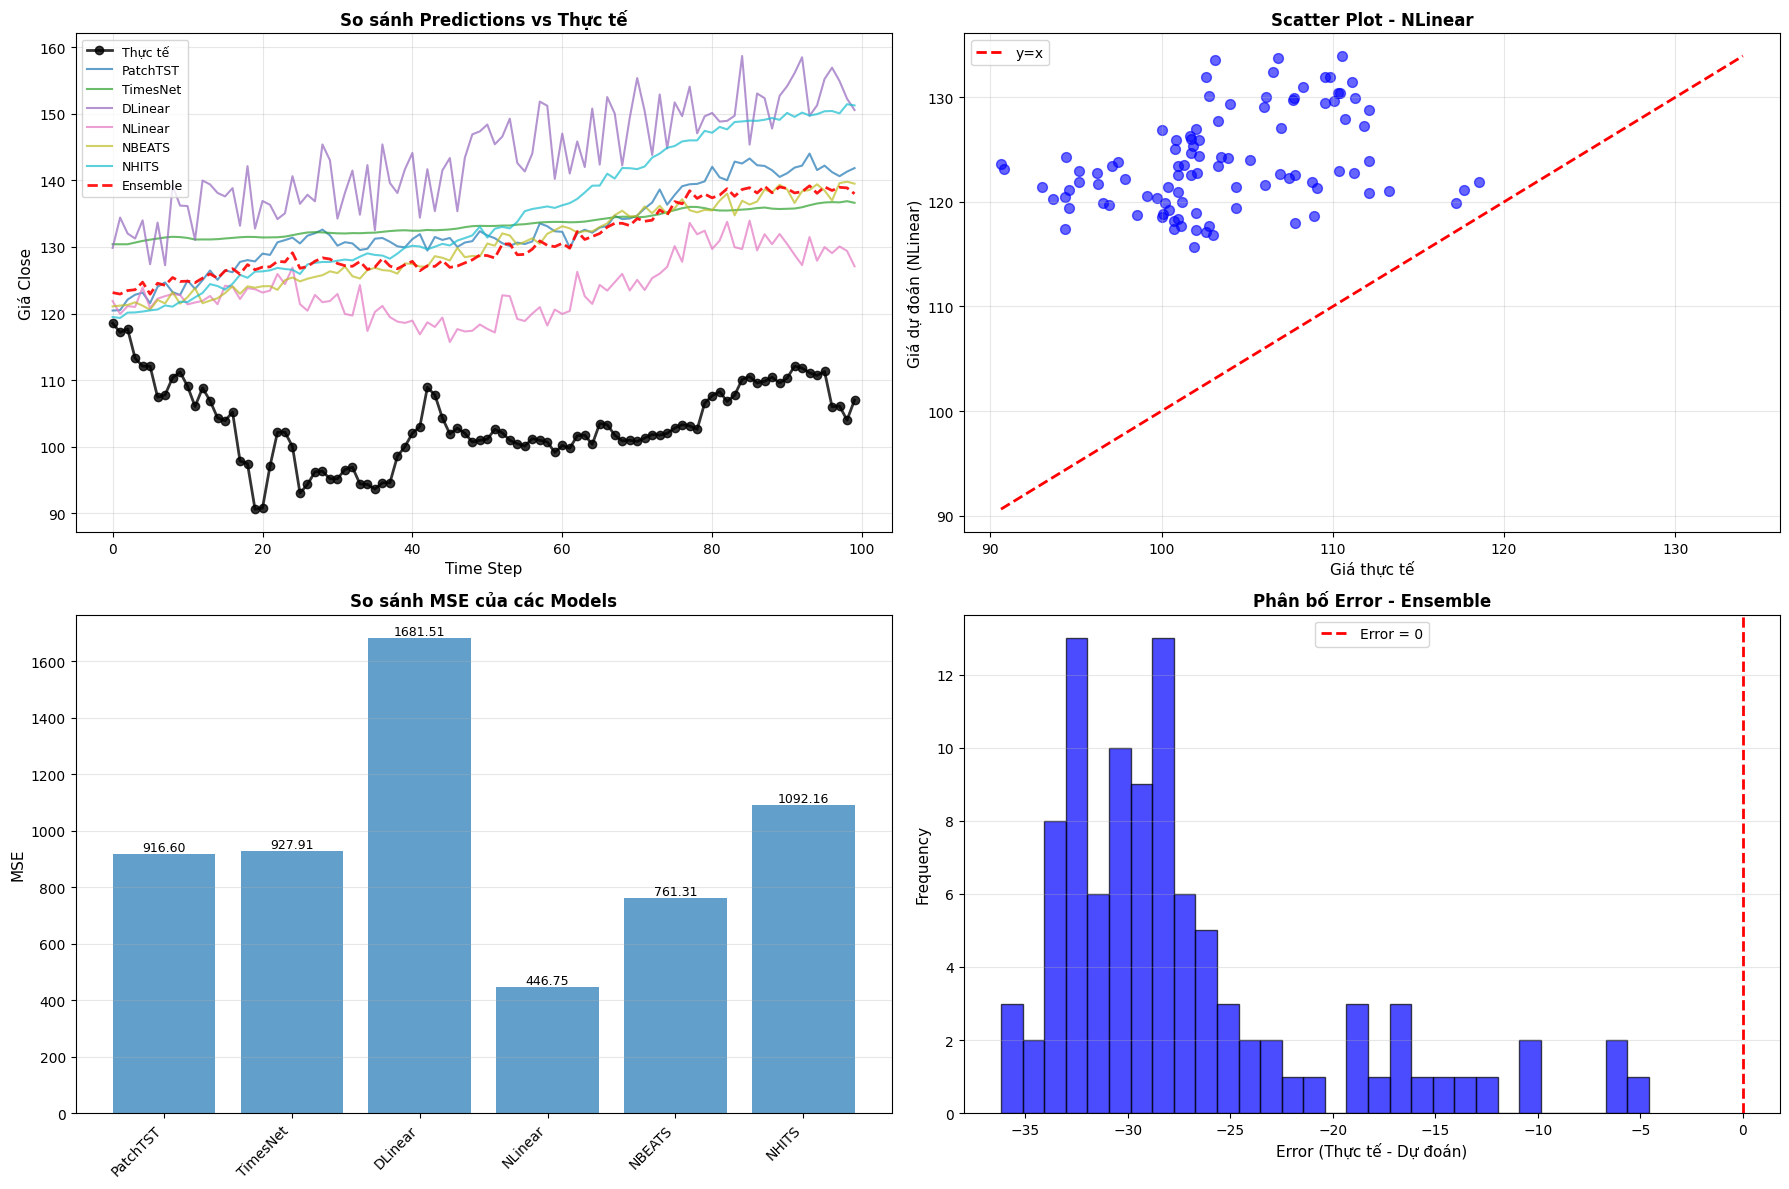

✓ Đã hiển thị biểu đồ so sánh


In [84]:
# Vẽ biểu đồ so sánh
if len(all_predictions) > 0 and 'y_true' in globals():
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # Plot 1: So sánh tất cả predictions vs actual
    ax1 = axes[0, 0]
    x_axis = np.arange(len(y_true))
    ax1.plot(x_axis, y_true, 'o-', label='Thực tế', linewidth=2, markersize=6, color='black', alpha=0.8)
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(all_predictions)))
    for i, (name, pred) in enumerate(all_predictions.items()):
        ax1.plot(x_axis, pred, '-', label=name, linewidth=1.5, alpha=0.7, color=colors[i])
    
    if 'future_close_100_ensemble' in globals():
        ax1.plot(x_axis, future_close_100_ensemble, '--', label='Ensemble', 
                linewidth=2, alpha=0.9, color='red')
    
    ax1.set_xlabel('Time Step', fontsize=11)
    ax1.set_ylabel('Giá Close', fontsize=11)
    ax1.set_title('So sánh Predictions vs Thực tế', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9, loc='best')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Scatter plot - Best model
    ax2 = axes[0, 1]
    if len(all_results) > 0:
        best_model_name = min(all_results, key=lambda x: x['MSE'])['Model']
        best_pred = all_predictions[best_model_name]
        
        ax2.scatter(y_true, best_pred, s=50, alpha=0.6, color='blue')
        min_val = min(y_true.min(), best_pred.min())
        max_val = max(y_true.max(), best_pred.max())
        ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='y=x')
        ax2.set_xlabel('Giá thực tế', fontsize=11)
        ax2.set_ylabel(f'Giá dự đoán ({best_model_name})', fontsize=11)
        ax2.set_title(f'Scatter Plot - {best_model_name}', fontsize=12, fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    # Plot 3: Bar chart - MSE comparison
    ax3 = axes[1, 0]
    if len(all_results) > 0:
        models = [r['Model'] for r in all_results]
        mses = [r['MSE'] for r in all_results]
        
        bars = ax3.bar(models, mses, alpha=0.7)
        ax3.set_ylabel('MSE', fontsize=11)
        ax3.set_title('So sánh MSE của các Models', fontsize=12, fontweight='bold')
        ax3.grid(True, alpha=0.3, axis='y')
        plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        # Thêm giá trị trên bars
        for bar, mse in zip(bars, mses):
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height,
                   f'{mse:.2f}', ha='center', va='bottom', fontsize=9)
    
    # Plot 4: Error distribution - Ensemble
    ax4 = axes[1, 1]
    if 'future_close_100_ensemble' in globals():
        errors = y_true - future_close_100_ensemble
        ax4.hist(errors, bins=30, color='blue', alpha=0.7, edgecolor='black')
        ax4.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error = 0')
        ax4.set_xlabel('Error (Thực tế - Dự đoán)', fontsize=11)
        ax4.set_ylabel('Frequency', fontsize=11)
        ax4.set_title('Phân bố Error - Ensemble', fontsize=12, fontweight='bold')
        ax4.legend()
        ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Đã hiển thị biểu đồ so sánh")
else:
    print("⚠️  Chưa có dữ liệu để vẽ biểu đồ")


## 11. Tạo Submission File


In [85]:
# Tạo submission file với predictions tốt nhất
print("="*70)
print("💾 TẠO SUBMISSION FILE")
print("="*70)

# Sử dụng ensemble nếu có, nếu không dùng best single model
if 'future_close_100_ensemble' in globals():
    final_predictions = future_close_100_ensemble
    method_name = "Ensemble"
    print(f"\n✓ Sử dụng Ensemble predictions")
elif len(all_predictions) > 0:
    # Tìm best model
    best_model_name = min(all_results, key=lambda x: x['MSE'])['Model']
    final_predictions = all_predictions[best_model_name]
    method_name = best_model_name
    print(f"\n✓ Sử dụng {best_model_name} predictions")
else:
    print("⚠️  Chưa có predictions nào. Vui lòng chạy các cells trước.")
    final_predictions = None

if final_predictions is not None:
    # Đảm bảo có đủ 100 predictions
    if len(final_predictions) < horizon:
        print(f"⚠️  Chỉ có {len(final_predictions)} predictions, cần {horizon}")
        # Pad với giá trị cuối cùng nếu thiếu
        final_predictions = np.pad(final_predictions, (0, horizon - len(final_predictions)), 
                                 mode='edge')
    else:
        final_predictions = final_predictions[:horizon]
    
    # Tạo submission file
    submission = pd.DataFrame({
        "id": np.arange(1, horizon + 1),
        "close": final_predictions
    })
    
    submission_file = f"submission_sota_{method_name.lower()}.csv"
    submission.to_csv(submission_file, index=False)
    
    print(f"\n✓ Đã tạo submission file: {submission_file}")
    print(f"   Shape: {submission.shape}")
    print(f"\n📅 10 dòng đầu:")
    print(submission.head(10))
    print(f"\n📅 10 dòng cuối:")
    print(submission.tail(10))
    
    # Tính thống kê
    print(f"\n📊 Thống kê predictions:")
    print(f"   - Min: {final_predictions.min():.2f}")
    print(f"   - Max: {final_predictions.max():.2f}")
    print(f"   - Mean: {final_predictions.mean():.2f}")
    print(f"   - Std: {final_predictions.std():.2f}")


💾 TẠO SUBMISSION FILE

✓ Sử dụng Ensemble predictions

✓ Đã tạo submission file: submission_sota_ensemble.csv
   Shape: (100, 2)

📅 10 dòng đầu:
   id       close
0   1  123.140233
1   2  122.923347
2   3  123.451406
3   4  123.577188
4   5  124.712382
5   6  122.911985
6   7  124.550509
7   8  124.239734
8   9  125.405248
9  10  124.817069

📅 10 dòng cuối:
     id       close
90   91  138.774272
91   92  138.113001
92   93  138.309564
93   94  139.182950
94   95  138.058900
95   96  139.025379
96   97  138.483153
97   98  138.955831
98   99  138.871706
99  100  137.987467

📊 Thống kê predictions:
   - Min: 122.91
   - Max: 139.18
   - Mean: 130.69
   - Std: 5.08


## 12. Tổng Kết và Kết Quả Cuối Cùng


In [86]:
print("="*70)
print("📊 TỔNG KẾT KẾT QUẢ")
print("="*70)

if len(all_results) > 0:
    results_df = pd.DataFrame(all_results)
    results_df = results_df.sort_values('MSE')
    
    print(f"\n📈 KẾT QUẢ TẤT CẢ CÁC MODELS (sắp xếp theo MSE):")
    print(results_df.to_string(index=False))
    
    best_model = results_df.iloc[0]
    print(f"\n🏆 MODEL TỐT NHẤT: {best_model['Model']}")
    print(f"   - MSE: {best_model['MSE']:.4f}")
    print(f"   - RMSE: {best_model['RMSE']:.4f}")
    print(f"   - MAE: {best_model['MAE']:.4f}")
    print(f"   - R²: {best_model['R²']:.4f}")
    print(f"   - MAPE: {best_model['MAPE']:.2f}%")
    
    if 'future_close_100_ensemble' in globals():
        print(f"\n🎯 ENSEMBLE RESULTS:")
        print(f"   - MSE: {mse_ensemble:.4f}")
        print(f"   - RMSE: {rmse_ensemble:.4f}")
        print(f"   - MAE: {mae_ensemble:.4f}")
        print(f"   - R²: {r2_ensemble:.4f}")
        print(f"   - MAPE: {mape_ensemble:.2f}%")
        
        improvement = ((best_model['MSE'] - mse_ensemble) / best_model['MSE']) * 100
        print(f"\n📊 Cải thiện so với Best Single Model: {improvement:+.2f}%")
    
    print(f"\n✓ Hoàn thành tất cả các models SOTA!")
else:
    print("⚠️  Chưa có kết quả nào")


📊 TỔNG KẾT KẾT QUẢ

📈 KẾT QUẢ TẤT CẢ CÁC MODELS (sắp xếp theo MSE):
   Model         MSE      RMSE       MAE         R²      MAPE
 NLinear  446.751404 21.136495 20.267292 -11.904753 19.878445
  NBEATS  761.305237 27.591760 26.521170 -20.990877 25.973991
PatchTST  916.597717 30.275365 29.184856 -25.476620 28.579082
TimesNet  927.910461 30.461623 29.902020 -25.803396 29.287884
   NHITS 1092.161987 33.047874 31.303383 -30.547924 30.551470
 DLinear 1681.508789 41.006204 40.008907 -47.571651 39.045673

🏆 MODEL TỐT NHẤT: NLinear
   - MSE: 446.7514
   - RMSE: 21.1365
   - MAE: 20.2673
   - R²: -11.9048
   - MAPE: 19.88%

🎯 ENSEMBLE RESULTS:
   - MSE: 787.4125
   - RMSE: 28.0609
   - MAE: 27.2059
   - R²: -21.7450
   - MAPE: 26.63%

📊 Cải thiện so với Best Single Model: -76.25%

✓ Hoàn thành tất cả các models SOTA!
